# 🔍 Deep Dive Exploratory Data Analysis

**UIDAI Aadhaar Insights Project**

This notebook performs comprehensive EDA on the Aadhaar datasets.

---

## 📌 Objectives
1. State-wise distribution analysis
2. Temporal trends and seasonality
3. Age demographic breakdown
4. Cross-dataset comparisons
5. Correlation analysis
6. State × Month heatmaps

In [19]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Define paths
DATA_DIR = Path('../data/processed')

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [20]:
# Load datasets
enrolment = pd.read_csv(DATA_DIR / 'cleaned_enrolment.csv', parse_dates=['date'])
demographic = pd.read_csv(DATA_DIR / 'cleaned_demographic.csv', parse_dates=['date'])
biometric = pd.read_csv(DATA_DIR / 'cleaned_biometric.csv', parse_dates=['date'])

print(f'✅ Loaded: Enrolment ({len(enrolment):,}), Demographic ({len(demographic):,}), Biometric ({len(biometric):,})')

✅ Loaded: Enrolment (981,295), Demographic (1,225,607), Biometric (1,476,599)


---

## 1️⃣ State-wise Distribution Analysis

Which states have the highest Aadhaar activity?

In [21]:
def get_state_totals(df, name):
    """Calculate state-wise totals."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if 'pincode' not in c.lower()]
    
    df['total'] = df[numeric_cols].sum(axis=1)
    state_totals = df.groupby('state')['total'].sum().sort_values(ascending=False)
    return state_totals

# Calculate totals
enrolment_states = get_state_totals(enrolment.copy(), 'Enrolment')
demographic_states = get_state_totals(demographic.copy(), 'Demographic')
biometric_states = get_state_totals(biometric.copy(), 'Biometric')

print('✅ State totals calculated')

✅ State totals calculated


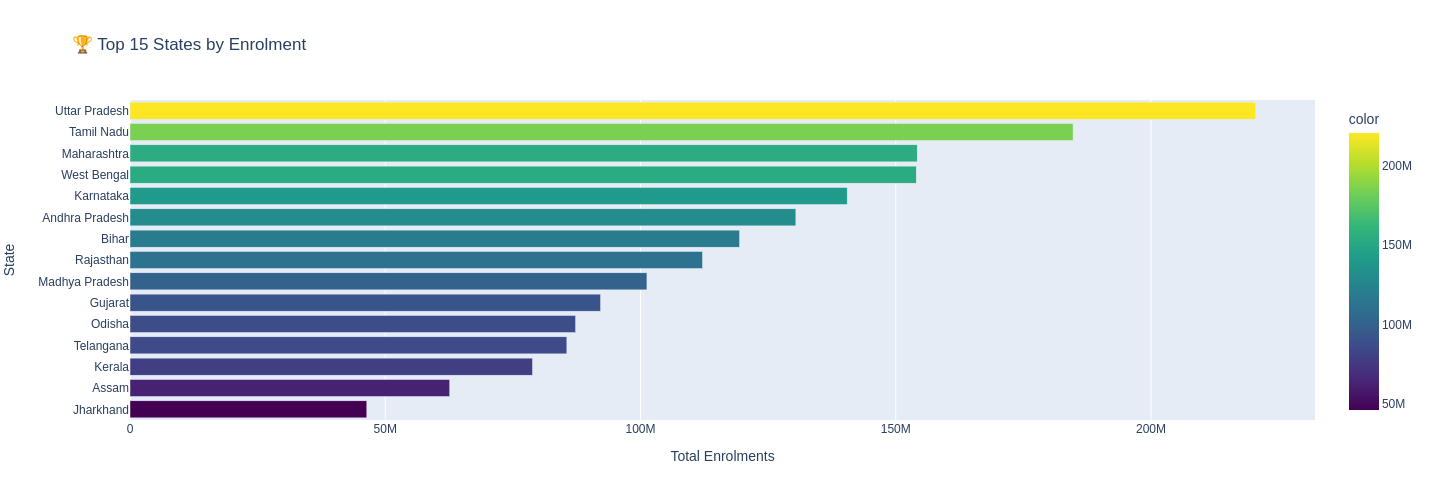

In [22]:
# Interactive bar chart - Enrolment by State
fig = px.bar(
    x=enrolment_states.head(15).values,
    y=enrolment_states.head(15).index,
    orientation='h',
    title='🏆 Top 15 States by Enrolment',
    labels={'x': 'Total Enrolments', 'y': 'State'},
    color=enrolment_states.head(15).values,
    color_continuous_scale='Viridis'
)
fig.update_layout(height=500, yaxis={'categoryorder': 'total ascending'})
fig.show()

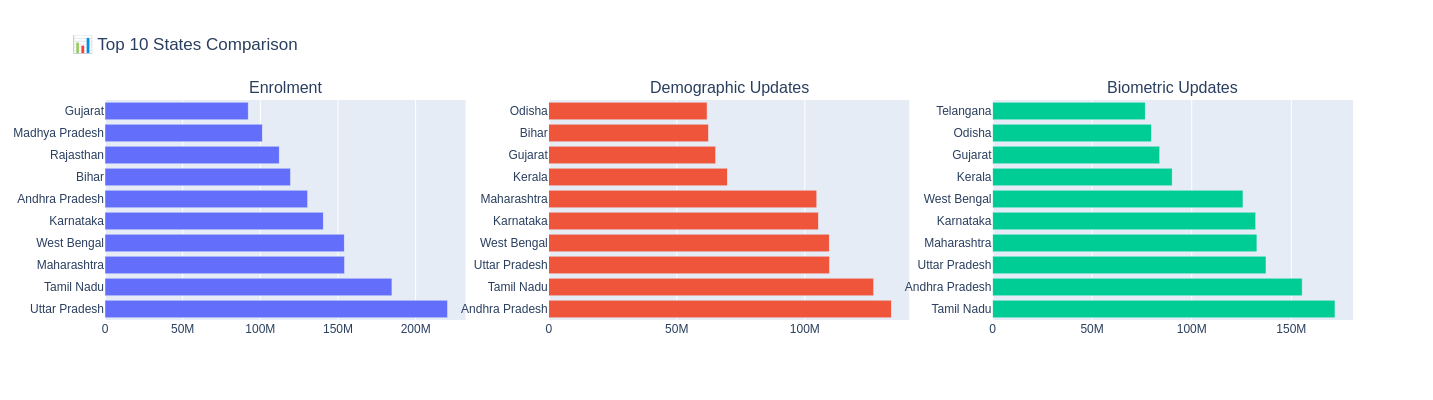

In [23]:
# Compare top states across all datasets
fig = make_subplots(rows=1, cols=3, subplot_titles=('Enrolment', 'Demographic Updates', 'Biometric Updates'))

for idx, (data, name) in enumerate([(enrolment_states, 'Enrolment'), 
                                      (demographic_states, 'Demographic'),
                                      (biometric_states, 'Biometric')]):
    top10 = data.head(10)
    fig.add_trace(
        go.Bar(x=top10.values, y=top10.index, orientation='h', name=name),
        row=1, col=idx+1
    )

fig.update_layout(height=400, title_text='📊 Top 10 States Comparison', showlegend=False)
fig.show()

In [24]:
# State distribution summary
print('=' * 60)
print('🏆 TOP STATES BY DATASET')
print('=' * 60)

print(f'\nEnrolment Top 5:')
for state, val in enrolment_states.head(5).items():
    print(f'  • {state}: {val:,.0f}')

print(f'\nDemographic Updates Top 5:')
for state, val in demographic_states.head(5).items():
    print(f'  • {state}: {val:,.0f}')

print(f'\nBiometric Updates Top 5:')
for state, val in biometric_states.head(5).items():
    print(f'  • {state}: {val:,.0f}')

🏆 TOP STATES BY DATASET

Enrolment Top 5:
  • Uttar Pradesh: 220,517,491
  • Tamil Nadu: 184,732,436
  • Maharashtra: 154,201,223
  • West Bengal: 154,012,178
  • Karnataka: 140,485,790

Demographic Updates Top 5:
  • Andhra Pradesh: 133,746,104
  • Tamil Nadu: 126,865,146
  • Uttar Pradesh: 109,622,693
  • West Bengal: 109,522,974
  • Karnataka: 105,292,675

Biometric Updates Top 5:
  • Tamil Nadu: 171,888,187
  • Andhra Pradesh: 155,396,800
  • Uttar Pradesh: 137,273,197
  • Maharashtra: 132,714,338
  • Karnataka: 132,103,891


---

## 2️⃣ Temporal Trends Analysis

How does Aadhaar activity change over time?

In [25]:
def get_monthly_trends(df):
    """Calculate monthly trends."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if 'pincode' not in c.lower()]
    
    df['total'] = df[numeric_cols].sum(axis=1)
    df['month'] = df['date'].dt.to_period('M').astype(str)
    return df.groupby('month')['total'].sum()

# Get monthly trends
enrolment_monthly = get_monthly_trends(enrolment.copy())
demographic_monthly = get_monthly_trends(demographic.copy())
biometric_monthly = get_monthly_trends(biometric.copy())

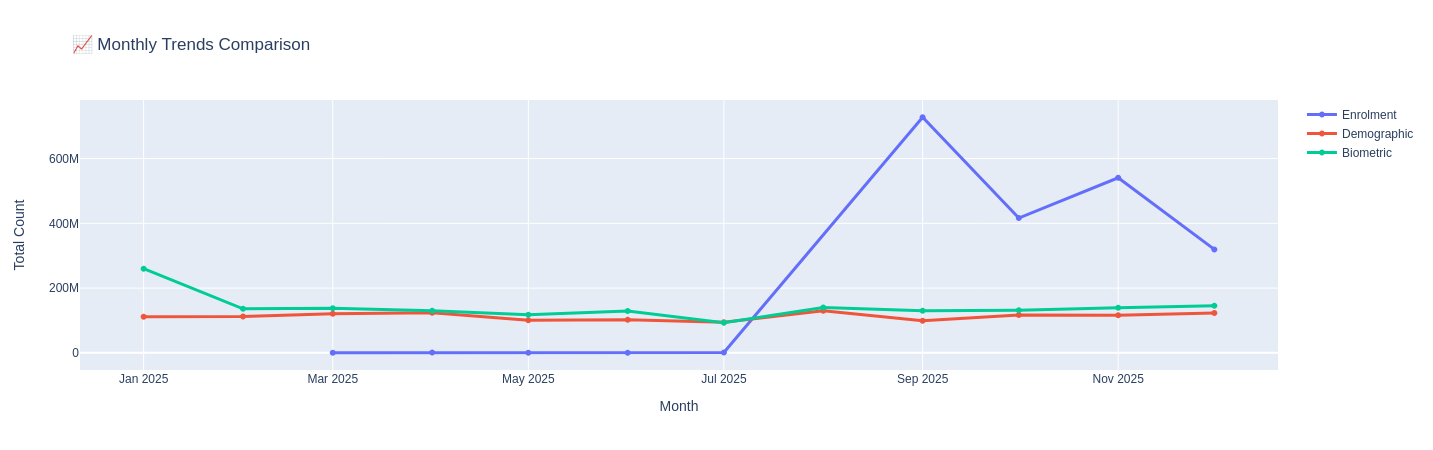

In [26]:
# Interactive line chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(enrolment_monthly.index), y=enrolment_monthly.values,
    mode='lines+markers', name='Enrolment', line=dict(width=3)
))
fig.add_trace(go.Scatter(
    x=list(demographic_monthly.index), y=demographic_monthly.values,
    mode='lines+markers', name='Demographic', line=dict(width=3)
))
fig.add_trace(go.Scatter(
    x=list(biometric_monthly.index), y=biometric_monthly.values,
    mode='lines+markers', name='Biometric', line=dict(width=3)
))

fig.update_layout(
    title='📈 Monthly Trends Comparison',
    xaxis_title='Month',
    yaxis_title='Total Count',
    height=450,
    hovermode='x unified'
)
fig.show()

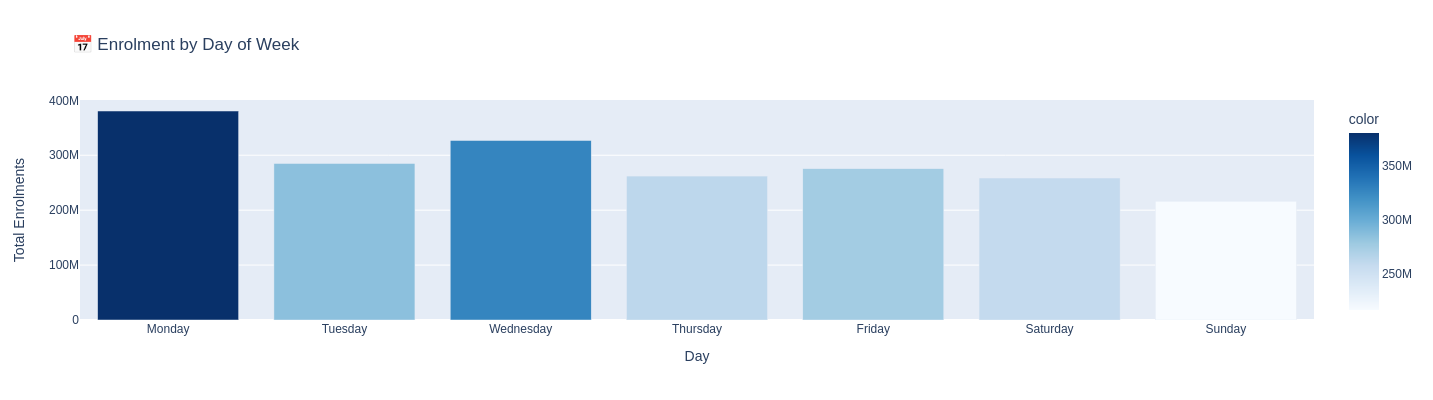

In [27]:
# Day of week analysis
enrolment['day_of_week'] = enrolment['date'].dt.day_name()

# Calculate total by day of week
numeric_cols = enrolment.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if 'pincode' not in c.lower()]
enrolment['total'] = enrolment[numeric_cols].sum(axis=1)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_totals = enrolment.groupby('day_of_week')['total'].sum().reindex(day_order)

fig = px.bar(
    x=dow_totals.index, y=dow_totals.values,
    title='📅 Enrolment by Day of Week',
    labels={'x': 'Day', 'y': 'Total Enrolments'},
    color=dow_totals.values,
    color_continuous_scale='Blues'
)
fig.update_layout(height=400)
fig.show()

---

## 3️⃣ Age Demographic Analysis

Understanding the age distribution of Aadhaar activities.

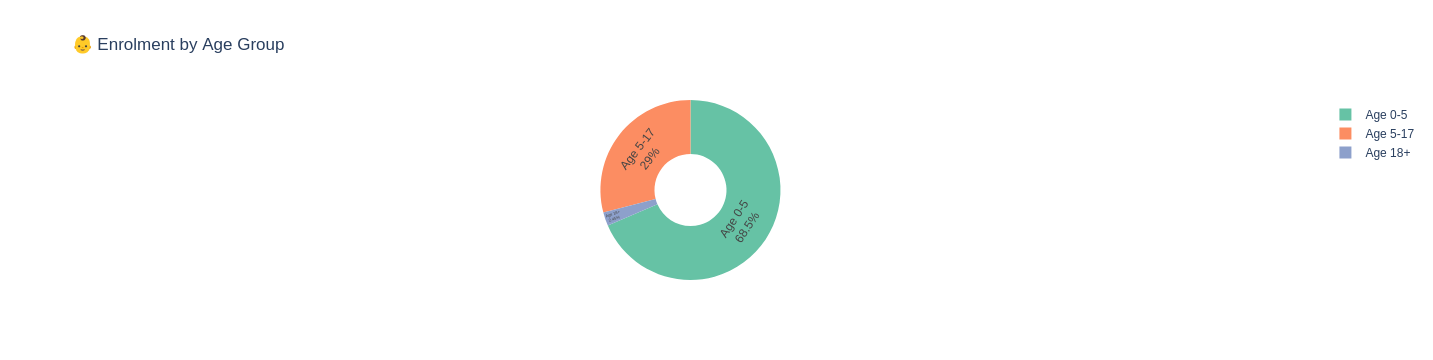

In [28]:
# Enrolment age groups
age_cols_enrolment = ['age_0_5', 'age_5_17', 'age_18_greater']
if all(col in enrolment.columns for col in age_cols_enrolment):
    age_enrolment = enrolment[age_cols_enrolment].sum()
    
    fig = px.pie(
        values=age_enrolment.values,
        names=['Age 0-5', 'Age 5-17', 'Age 18+'],
        title='👶 Enrolment by Age Group',
        color_discrete_sequence=px.colors.qualitative.Set2,
        hole=0.4
    )
    fig.update_traces(textposition='inside', textinfo='percent+label')
    fig.show()
else:
    print('Age columns not found in enrolment dataset')

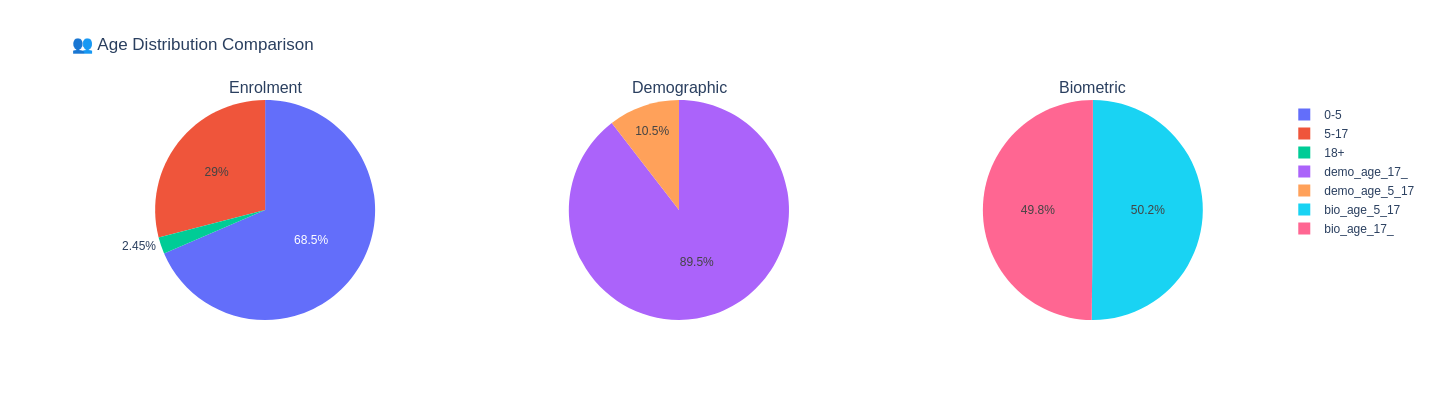

In [29]:
# Compare age distribution across datasets
fig = make_subplots(rows=1, cols=3, specs=[[{'type': 'pie'}, {'type': 'pie'}, {'type': 'pie'}]],
                    subplot_titles=['Enrolment', 'Demographic', 'Biometric'])

# Enrolment
if all(col in enrolment.columns for col in ['age_0_5', 'age_5_17', 'age_18_greater']):
    age_data = enrolment[['age_0_5', 'age_5_17', 'age_18_greater']].sum()
    fig.add_trace(go.Pie(labels=['0-5', '5-17', '18+'], values=age_data.values, name='Enrolment'), row=1, col=1)

# Demographic
demo_age_cols = [c for c in demographic.columns if 'age' in c.lower()]
if demo_age_cols:
    age_data = demographic[demo_age_cols].sum()
    fig.add_trace(go.Pie(labels=age_data.index, values=age_data.values, name='Demographic'), row=1, col=2)

# Biometric
bio_age_cols = [c for c in biometric.columns if 'age' in c.lower()]
if bio_age_cols:
    age_data = biometric[bio_age_cols].sum()
    fig.add_trace(go.Pie(labels=age_data.index, values=age_data.values, name='Biometric'), row=1, col=3)

fig.update_layout(title_text='👥 Age Distribution Comparison', height=400)
fig.show()

---

## 4️⃣ State × Month Heatmap

Visualize patterns across states and time.

In [30]:
# Create state x month pivot
enrolment_copy = enrolment.copy()
numeric_cols = enrolment_copy.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if 'pincode' not in c.lower()]

enrolment_copy['total'] = enrolment_copy[numeric_cols].sum(axis=1)
enrolment_copy['month'] = enrolment_copy['date'].dt.to_period('M').astype(str)

pivot = enrolment_copy.groupby(['state', 'month'])['total'].sum().unstack(fill_value=0)

# Top 15 states
top_states = enrolment_copy.groupby('state')['total'].sum().nlargest(15).index
pivot_top = pivot.loc[top_states]

In [31]:
# Heatmap
fig = px.imshow(
    pivot_top.values,
    x=pivot_top.columns.tolist(),
    y=pivot_top.index.tolist(),
    color_continuous_scale='YlOrRd',
    title='🔥 Enrolment Heatmap: State × Month (Top 15 States)',
    labels={'color': 'Enrolments'}
)
fig.update_layout(height=500, xaxis_tickangle=45)
fig.show()

---

## 5️⃣ Correlation Analysis

Are there correlations between age groups?

In [32]:
# Correlation matrix for enrolment
numeric_cols = ['age_0_5', 'age_5_17', 'age_18_greater']
if all(col in enrolment.columns for col in numeric_cols):
    corr_matrix = enrolment[numeric_cols].corr()
    
    fig = px.imshow(
        corr_matrix,
        text_auto='.2f',
        title='📊 Correlation Matrix: Enrolment Age Groups',
        color_continuous_scale='RdBu_r',
        zmin=-1, zmax=1
    )
    fig.update_layout(height=400)
    fig.show()

In [33]:
# Cross-dataset comparison by state
comparison = pd.DataFrame({
    'Enrolment': enrolment_states,
    'Demographic': demographic_states,
    'Biometric': biometric_states
}).dropna()

# Correlation between datasets
cross_corr = comparison.corr()
print('=' * 60)
print('📊 CROSS-DATASET CORRELATION')
print('=' * 60)
print(cross_corr.round(3))

📊 CROSS-DATASET CORRELATION
             Enrolment  Demographic  Biometric
Enrolment        1.000        0.966      0.967
Demographic      0.966        1.000      0.998
Biometric        0.967        0.998      1.000


---

## 6️⃣ District-Level Analysis

Drill down to district level.

In [34]:
# Top districts
enrolment_copy = enrolment.copy()
numeric_cols = enrolment_copy.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if 'pincode' not in c.lower()]

enrolment_copy['total'] = enrolment_copy[numeric_cols].sum(axis=1)
district_totals = enrolment_copy.groupby(['state', 'district'])['total'].sum().sort_values(ascending=False)

print('🏆 TOP 20 DISTRICTS BY ENROLMENT:')
print('=' * 60)
for i, ((state, district), val) in enumerate(district_totals.head(20).items(), 1):
    print(f'{i:2}. {district} ({state}): {val:,.0f}')

🏆 TOP 20 DISTRICTS BY ENROLMENT:
 1. Pune (Maharashtra): 26,571,124
 2. North 24 Parganas (West Bengal): 26,160,014
 3. Barddhaman (West Bengal): 21,459,228
 4. Bengaluru (Karnataka): 21,222,752
 5. Malappuram (Kerala): 18,991,426
 6. Jaipur (Rajasthan): 18,596,740
 7. South 24 Parganas (West Bengal): 18,444,786
 8. Murshidabad (West Bengal): 18,317,150
 9. K.v. Rangareddy (Telangana): 18,118,690
10. Hooghly (West Bengal): 17,820,112
11. Kancheepuram (Tamil Nadu): 17,637,172
12. Tirunelveli (Tamil Nadu): 17,549,168
13. East Godavari (Andhra Pradesh): 16,954,408
14. Thrissur (Kerala): 16,852,298
15. Paschim Medinipur (West Bengal): 16,839,740
16. Thane (Maharashtra): 16,825,798
17. Purba Medinipur (West Bengal): 16,775,030
18. Mumbai (Maharashtra): 16,750,400
19. Guntur (Andhra Pradesh): 16,518,574
20. Vellore (Tamil Nadu): 16,390,756


In [35]:
# Top districts bar chart
top20_districts = district_totals.head(20)
labels = [f"{d[1]} ({d[0][:10]}...)" if len(d[0]) > 10 else f"{d[1]} ({d[0]})" for d in top20_districts.index]

fig = px.bar(
    x=top20_districts.values,
    y=labels,
    orientation='h',
    title='🏆 Top 20 Districts by Enrolment',
    labels={'x': 'Total Enrolments', 'y': 'District (State)'},
    color=top20_districts.values,
    color_continuous_scale='Viridis'
)
fig.update_layout(height=600, yaxis={'categoryorder': 'total ascending'})
fig.show()

---

## 📌 Key Insights

### State-wise Patterns:
- **Uttar Pradesh** leads in enrolment and demographic updates
- **Maharashtra** leads in biometric updates
- Geographic distribution reflects population density

### Temporal Patterns:
- Clear monthly trends with some spikes
- Day-of-week patterns show weekday preference
- Seasonal variations visible in heatmaps

### Age Demographics:
- Child enrolment (0-5) dominates new registrations
- Adults (18+) dominate update activities
- Age patterns vary by activity type
